# Algoritmos - Actividad Guiada 1

* **Nombre:** Marcos Lévano Huamaccto
* **Link a Google Colab:** [Acceder al Cuaderno Interactivo](https://colab.research.google.com/drive/1BbMnufvrap5TzEqz7K1nAmOASJFjuI3u?usp=sharing)
* **Repositorio GitHub:** [Ver Código Fuente](https://github.com/marlev88/AlgoritmosOptimizacion)

## Ejecuciones

### 1) Torres de Hanoi con Divide y vencerás

In [75]:
def Torres_Hanoi(N, desde, hasta):
  if N ==1 :
    print("Lleva la ficha " ,desde , " hasta ", hasta )

  else:
    #Torres_Hanoi(N-1, desde, 6-desde-hasta )
    Torres_Hanoi(N-1, desde, 6-desde-hasta )
    print("Lleva la ficha " ,desde , " hasta ", hasta )
    #Torres_Hanoi(N-1,6-desde-hasta, hasta )
    Torres_Hanoi(N-1, 6-desde-hasta  , hasta )


Torres_Hanoi(3, 1 , 3)

Lleva la ficha  1  hasta  3
Lleva la ficha  1  hasta  2
Lleva la ficha  3  hasta  2
Lleva la ficha  1  hasta  3
Lleva la ficha  2  hasta  1
Lleva la ficha  2  hasta  3
Lleva la ficha  1  hasta  3


<center>
<div style="border: 0px solid #333; padding: 0px; display: inline-block; width: 650px; height=500;">

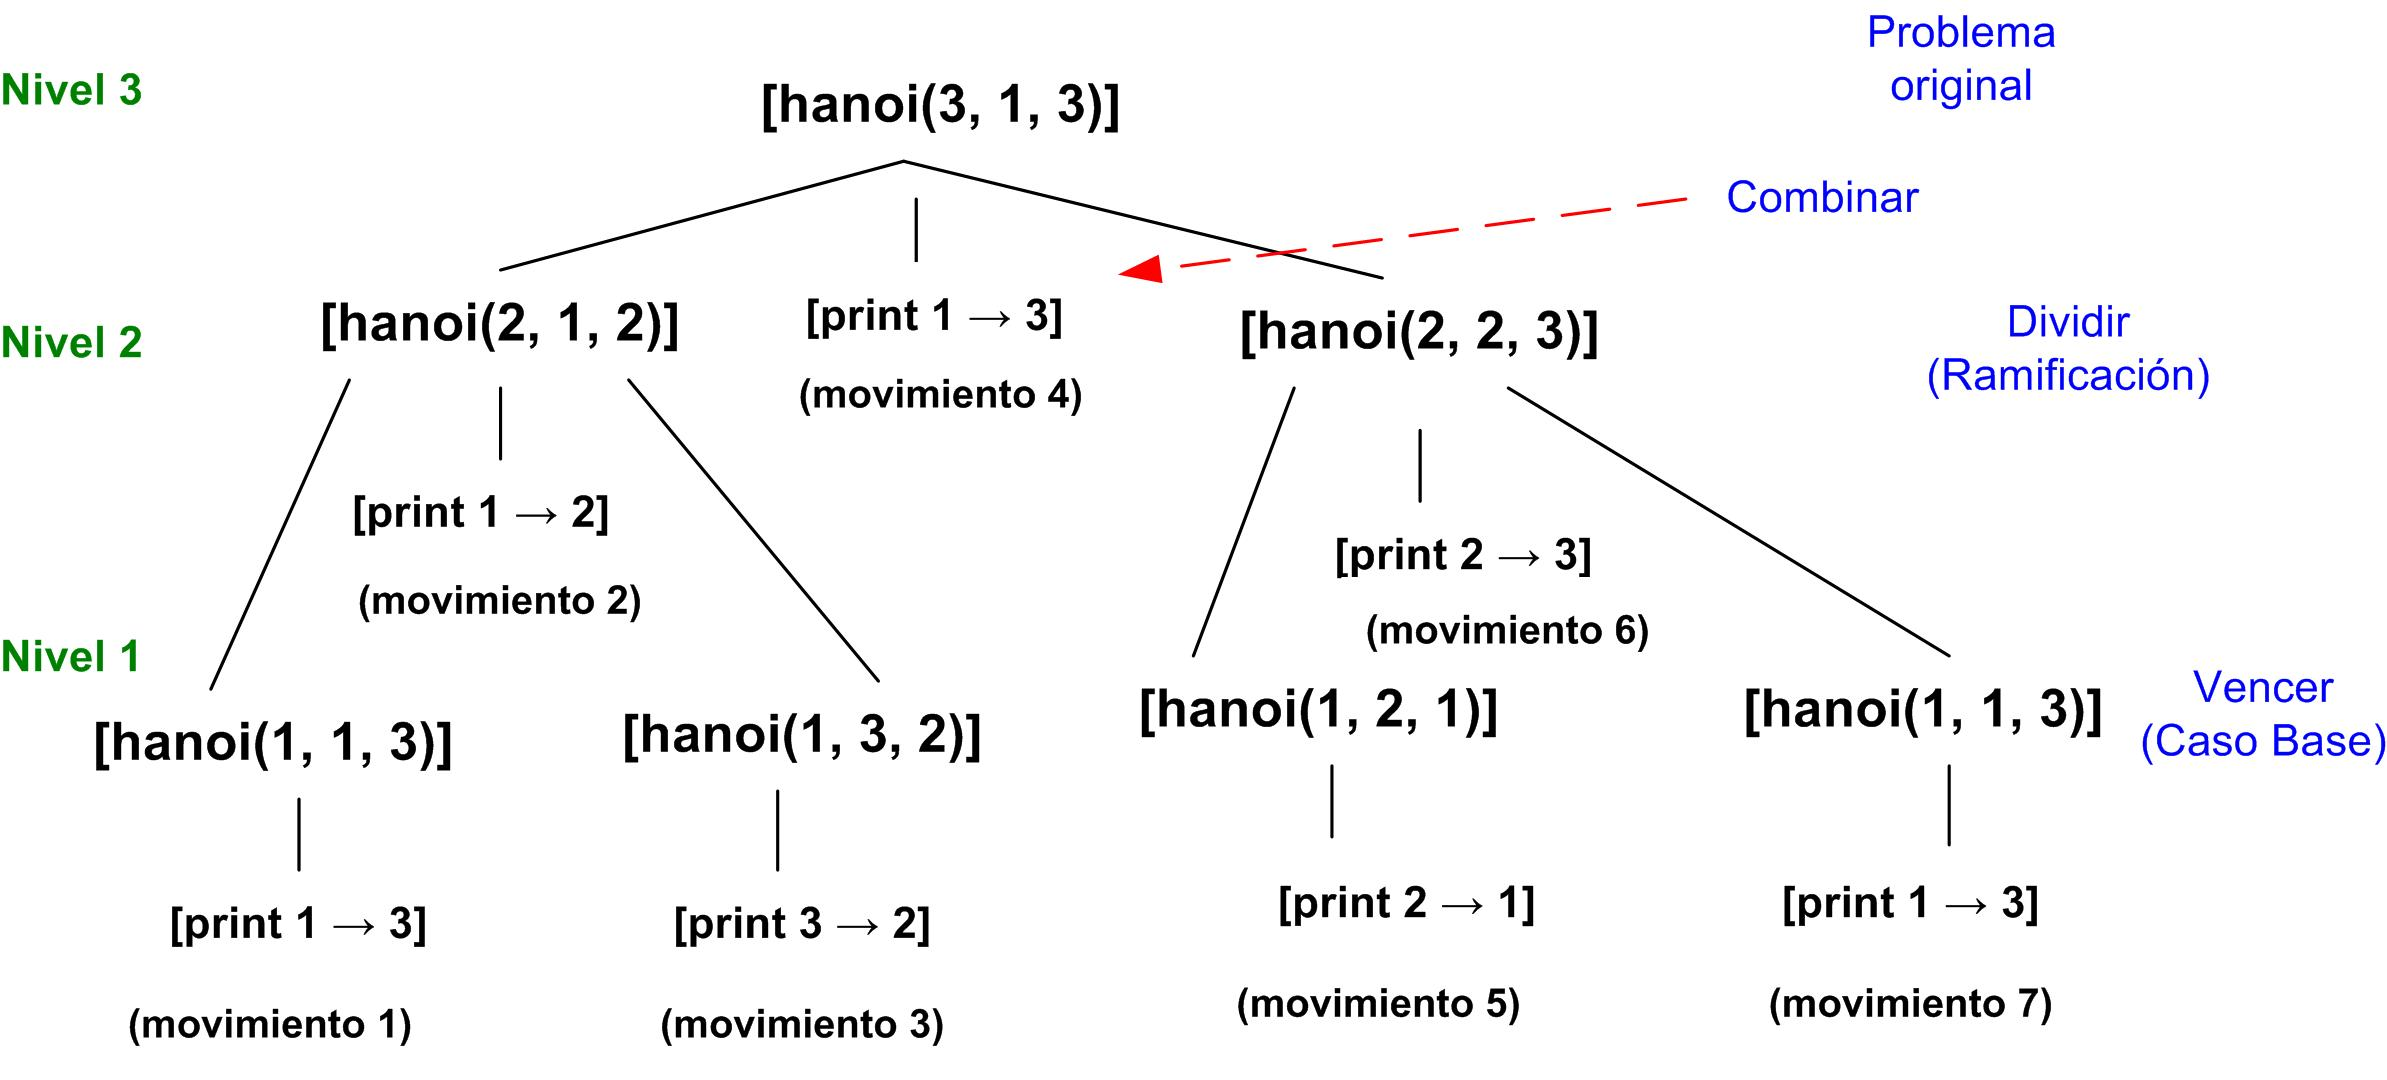

</div>

<p style="margin-top: 8px;"><em>Fig. 1. Árbol de llamadas recursivas, (Elaboración propia).</em></p>
</center>

**Complejidad**

Respecto al numero de operaciones, 
$$O(2^{N})$$

Por ejemplo: para n=3, $2^{N} -1$ = $2^{3} -1$ = 7 movimientos. Cada vez que se suma un disco el tamañao del árbol se duplica.

Para n=4,  $2^{N} -1$ = $2^{4} -1$ = 15 movimientos.

### 2) Sucesión de Fibonacci

In [76]:
# https://es.wikipedia.org/wiki/Sucesi%C3%B3n_de_Fibonacci
# Calculo del termino n-simo de la suscesión de Fibonacci
def Fibonacci(N:int):
  if N < 2:
    return 1
  else:
    return Fibonacci(N-1)+Fibonacci(N-2)

Fibonacci(5)

8

**Forma secuencial**

In [77]:
def fib_iter(n):
    if n < 2:
        return 1
    a, b = 1, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

print(f"Fibonacci es: {fib_iter(5)}")


Fibonacci es: 8


**Complejidad**

Respecto al numero de operaciones simples que tendría que realizar el método para el fibonacci de la forma secuencial, sería:

$$O(N)$$

Teniendo un complejidad lineal. ¿Por qué es lineal?, el tiempo que tarda el programa es directamente proporcional al número \(N\) que le pases. Si pides Fibonacci(100), el bucle dará unas 99 vueltas. Hace una sola operación matemática por cada número del camino.

Por otro lado, comparación con de la forma recursiva: El método recursivo original tarda un tiempo exponencial $O(2^N)$ (abriendo un árbol gigante de funciones repetidas).

Para \(N=50\), el recursivo haría miles de millones de cálculos, mientras que el secuencial solo hace 50 sumas.

### Devolución de cambio por técnica voraz

In [78]:
def cambio_monedas(N, SM):
  SOLUCION = [0]*len(SM)   # SOLUCION = [0,0,0,0,..]
  ValorAcumulado = 0

  for i,valor in enumerate(SM):
    monedas =  (N-ValorAcumulado)//valor
    SOLUCION[i] = monedas
    ValorAcumulado = ValorAcumulado + monedas*valor

    if ValorAcumulado == N:
      return SOLUCION


cambio_monedas(15,[25,10,5,1])

[0, 1, 1, 0]

**Desarrollo de un ejemplo**

Queremos dar un vuelto de $ 874 utilizando las monedas de pesos chilenos: [500, 100, 50, 10, 5, 1]

In [79]:
cambio_monedas(874, [500, 100, 50, 10, 5, 1])

[1, 3, 1, 2, 0, 4]

El caso del procedimiento crea la lista inicial SOLUCION = [0, 0, 0, 0, 0, 0] y empieza a devorar la cantidad en el bucle.

1) Moneda de 500: ¿Cuántas de 500 caben en 874? El cálculo 874 // 500 da 1. SOLUCION = [1, 0, 0, 0, 0, 0].  
Valor Acumulado = 500. Quedan por cubrir: 374.

2) Moneda de 100: ¿Cuántas de 100 caben en los 374 restantes? El cálculo 374 // 100 da 3. SOLUCION = [1, 3, 0, 0, 0, 0].  Valor Acumulado = 800. Quedan por cubrir: 74.

3) Moneda de 50: ¿Cuántas de 50 caben en 74? El cálculo 74 // 50 da 1. SOLUCION = [1, 3, 1, 0, 0, 0]. Valor Acumulado = 850. Quedan por cubrir: 24.

4) Moneda de 10: ¿Cuántas de 10 caben en 24? El cálculo 24 // 10 da 2. SOLUCION = [1, 3, 1, 2, 0, 0]. Valor Acumulado = 870. Quedan por cubrir: 4.

5) Moneda de 5: ¿Cuántas de 5 caben en 4? El cálculo 4 // 5 da 0. SOLUCION = [1, 3, 1, 2, 0, 0]. Valor Acumulado = 870. Quedan por cubrir: 4.

6) Moneda de 1: ¿Cuántas de 1 caben en 4? El cálculo 4 // 1 da 4. SOLUCION = [1, 3, 1, 2, 0, 4]. Valor Acumulado = 874.Fin: El if detecta que el valor acumulado llegó a 874 y corta el programa.


**Complejidad**

Complejidad de Tiempo: Como la lista tiene 6 tipos de monedas, el bucle da exactamente 6 vueltas. Se resuelve al instante.

La complejidad en el tiempo es lineal respecto al número de monedas,

$$O(M)$$

Por qué es lineal $O(M)$: El procedimiento utiliza un solo bucle $for$ que recorre la lista SM de principio a fin. Da exactamente una vuelta por cada tipo de moneda disponible.

### N-Reinas por técnica de vuelta atrás


In [80]:
def escribe(S):
  n = len(S)
  for x in range(n):
    print("")
    for i in range(n):
      if S[i] == x+1:
        print(" X " , end="")
      else:
        print(" - ", end="")

# Verificación si la solución en válida
def es_prometedora(SOLUCION,etapa):
  #print(SOLUCION)
  #Si la solución tiene dos valores iguales no es valida => Dos reinas en la misma fila
  for i in range(etapa+1):
    #print("El valor " + str(SOLUCION[i]) + " está " +  str(SOLUCION.count(SOLUCION[i])) + " veces")
    if SOLUCION.count(SOLUCION[i]) > 1:
      return False

    #Verifica las diagonales
    for j in range(i+1, etapa +1 ):
      #print("Comprobando diagonal de " + str(i) + " y " + str(j))
      if abs(i-j) == abs(SOLUCION[i]-SOLUCION[j]) : return False
  return True


def reinas(N, solucion=[], etapa=0):
  if len(solucion) == 0:
      solucion=[0 for i in range(N)]

  for i in range(1, N+1):
    solucion[etapa] = i

    if es_prometedora(solucion, etapa):
      if etapa == N-1:
        print(solucion)
        #escribe(solucion)
        print()
      else:
        escribe(solucion)
        print()
        reinas(N, solucion, etapa+1)
    else:
      None

    solucion[etapa] = 0

reinas(4)


 X  -  -  - 
 -  -  -  - 
 -  -  -  - 
 -  -  -  - 

 X  -  -  - 
 -  -  -  - 
 -  X  -  - 
 -  -  -  - 

 X  -  -  - 
 -  -  -  - 
 -  -  -  - 
 -  X  -  - 

 X  -  -  - 
 -  -  X  - 
 -  -  -  - 
 -  X  -  - 

 -  -  -  - 
 X  -  -  - 
 -  -  -  - 
 -  -  -  - 

 -  -  -  - 
 X  -  -  - 
 -  -  -  - 
 -  X  -  - 

 -  -  X  - 
 X  -  -  - 
 -  -  -  - 
 -  X  -  - 
[2, 4, 1, 3]


 -  -  -  - 
 -  -  -  - 
 X  -  -  - 
 -  -  -  - 

 -  X  -  - 
 -  -  -  - 
 X  -  -  - 
 -  -  -  - 

 -  X  -  - 
 -  -  -  - 
 X  -  -  - 
 -  -  X  - 
[3, 1, 4, 2]


 -  -  -  - 
 -  -  -  - 
 -  -  -  - 
 X  -  -  - 

 -  X  -  - 
 -  -  -  - 
 -  -  -  - 
 X  -  -  - 

 -  X  -  - 
 -  -  -  - 
 -  -  X  - 
 X  -  -  - 

 -  -  -  - 
 -  X  -  - 
 -  -  -  - 
 X  -  -  - 



<center>
<div style="border: 0px solid #333; padding: 0px; display: inline-block; width: 450px; height=500;">

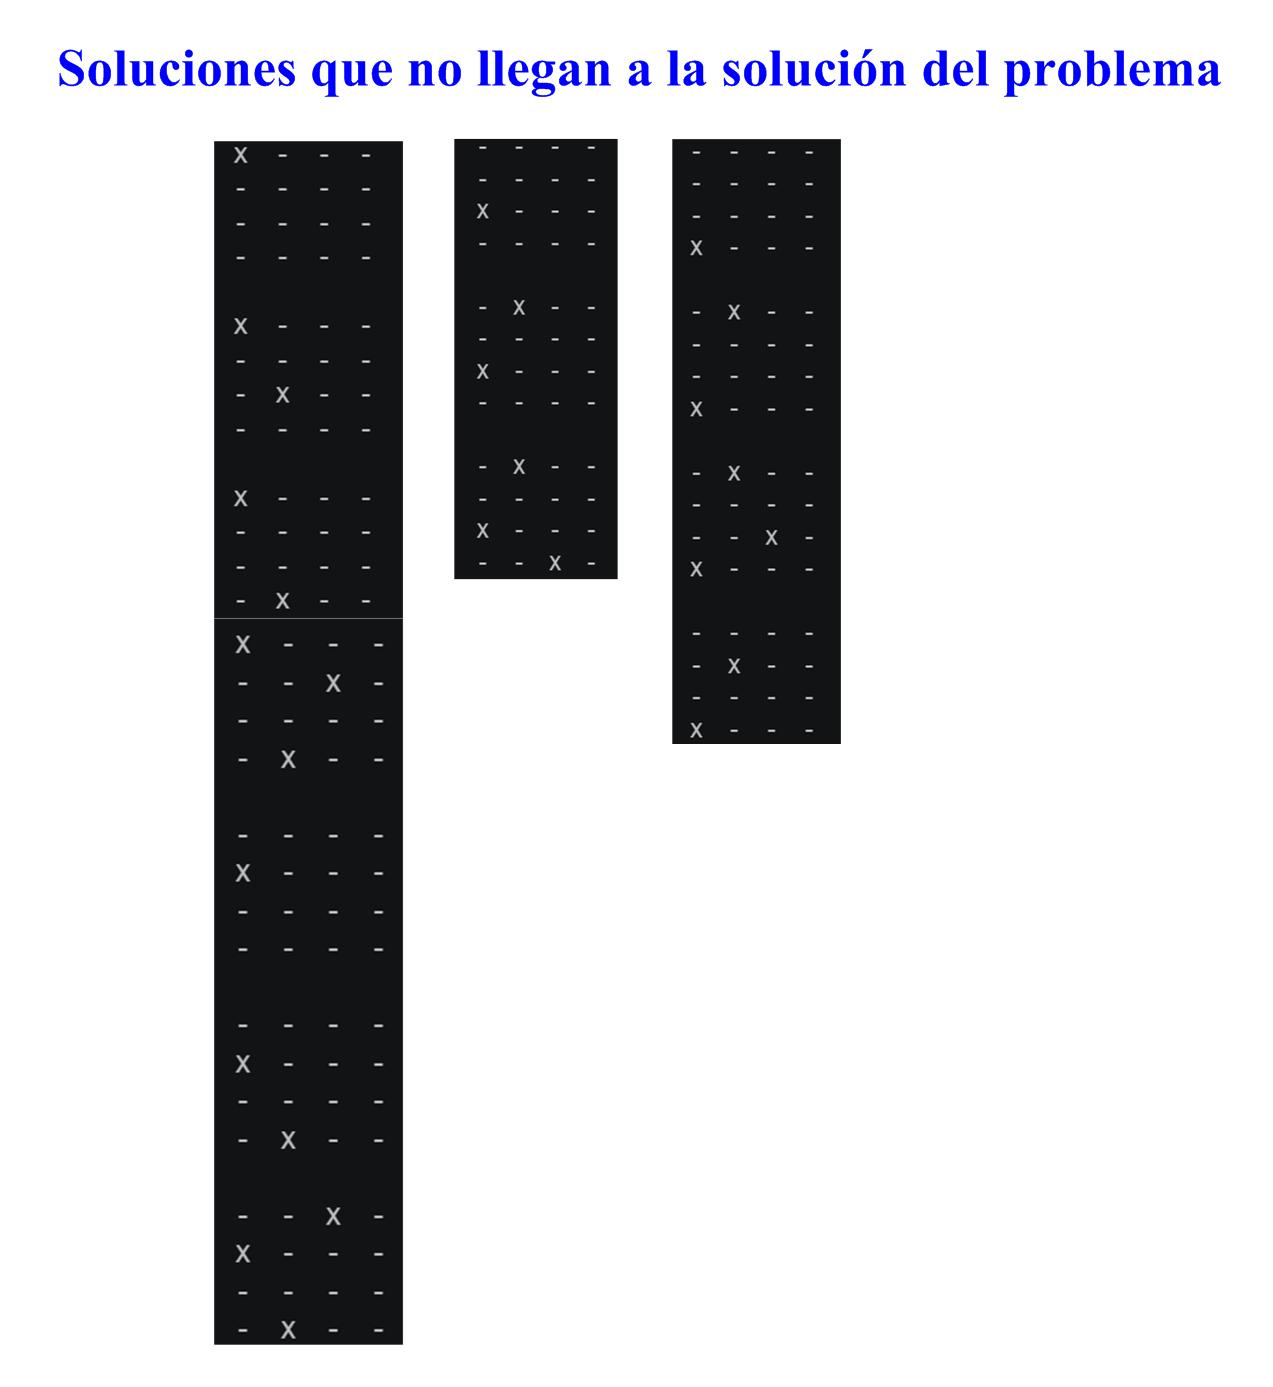

</div>

<p style="margin-top: 8px;"><em>Fig. 2. Soluciones que no llevan al objetivo del problema, (Elaboración propia).</em></p>
</center>

In [81]:
reinas(4)


 X  -  -  - 
 -  -  -  - 
 -  -  -  - 
 -  -  -  - 

 X  -  -  - 
 -  -  -  - 
 -  X  -  - 
 -  -  -  - 

 X  -  -  - 
 -  -  -  - 
 -  -  -  - 
 -  X  -  - 

 X  -  -  - 
 -  -  X  - 
 -  -  -  - 
 -  X  -  - 

 -  -  -  - 
 X  -  -  - 
 -  -  -  - 
 -  -  -  - 

 -  -  -  - 
 X  -  -  - 
 -  -  -  - 
 -  X  -  - 

 -  -  X  - 
 X  -  -  - 
 -  -  -  - 
 -  X  -  - 
[2, 4, 1, 3]


 -  -  -  - 
 -  -  -  - 
 X  -  -  - 
 -  -  -  - 

 -  X  -  - 
 -  -  -  - 
 X  -  -  - 
 -  -  -  - 

 -  X  -  - 
 -  -  -  - 
 X  -  -  - 
 -  -  X  - 
[3, 1, 4, 2]


 -  -  -  - 
 -  -  -  - 
 -  -  -  - 
 X  -  -  - 

 -  X  -  - 
 -  -  -  - 
 -  -  -  - 
 X  -  -  - 

 -  X  -  - 
 -  -  -  - 
 -  -  X  - 
 X  -  -  - 

 -  -  -  - 
 -  X  -  - 
 -  -  -  - 
 X  -  -  - 


### Viaje por el rio. Programación dinámica

In [ ]:
TARIFAS = [
[0,5,4,3,999,999,999],
[999,0,999,2,3,999,11],
[999,999, 0,1,999,4,10],
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]



################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]
  RUTA = [ [""]*N for i in [""]*N]

  for i in range(0,N-1):
    RUTA[i][i] = i             #Para ir de i a i se "pasa por i"
    PRECIOS[i][i] = 0          #Para ir de i a i se se paga 0
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k          #Anota que para ir de i a j hay que pasar por k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA
################################################################

PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

#Determinar la ruta con Recursividad
def calcular_ruta(RUTA, desde, hasta):
  if desde == hasta:
    #print("Ir a :" + str(desde))
    return ""
  else:
    return str(calcular_ruta( RUTA, desde, RUTA[desde][hasta])) +  \
                ',' + \
                str(RUTA[desde][hasta] \
              )

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)

PRECIOS
[0, 5, 4, 3, 8, 8, 11]
[9999, 0, 999, 2, 3, 8, 7]
[9999, 9999, 0, 1, 6, 4, 7]
[9999, 9999, 9999, 0, 5, 6, 9]
[9999, 9999, 9999, 9999, 0, 999, 4]
[9999, 9999, 9999, 9999, 9999, 0, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
[0, 0, 0, 0, 1, 2, 5]
['', 1, 1, 1, 1, 3, 4]
['', '', 2, 2, 3, 2, 5]
['', '', '', 3, 3, 3, 3]
['', '', '', '', 4, 4, 4]
['', '', '', '', '', 5, 5]
['', '', '', '', '', '', '']

La ruta es:


',0,2,5'

# Pregunta adicional de la actividad

<center>
<div style="border: 0px solid #333; padding: 0px; display: inline-block; width: 600px; height=700;">

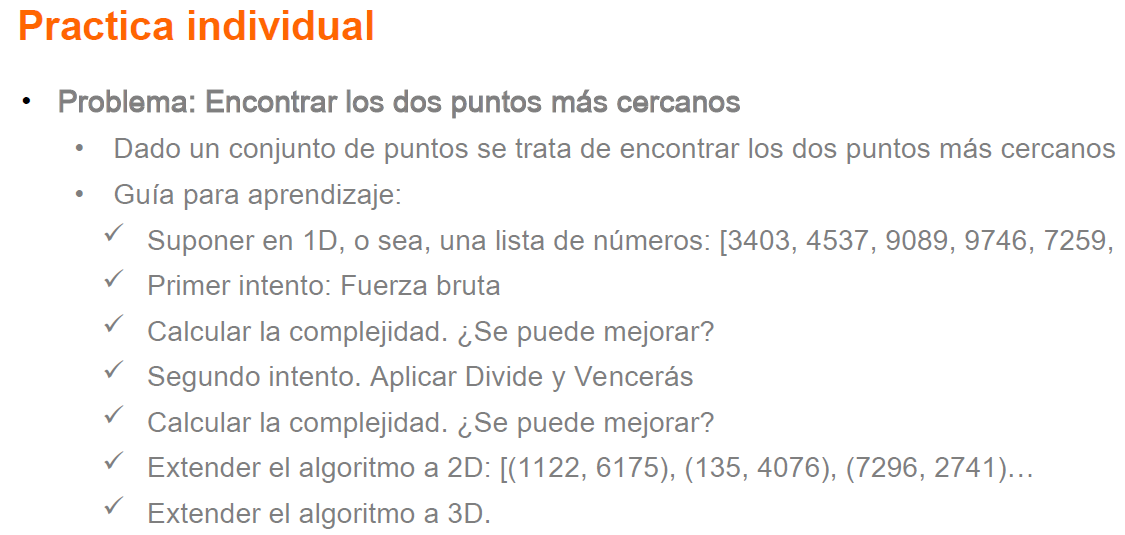

</div>

<p style="margin-top: 8px;"><em>Fig. 1. Pregunta adicional de la actividad, (Camacho, 2026a, diapositiva 27).</em></p>
</center>

**Introducción**

Para efectos del análisis, se consideró una versión reducida del problema en tres escenarios de creciente complejidad dimensional. En primer lugar, se abordó el caso unidimensional (1D), resolviéndolo mediante un enfoque de fuerza bruta y posteriormente utilizando la estrategia de divide y vencerás. A continuación, se extendió el problema al espacio bidimensional (2D), aplicando nuevamente ambos enfoques con el fin de comparar su comportamiento y eficiencia. Finalmente, el problema fue escalado a un espacio tridimensional (3D), resolviéndose tanto mediante fuerza bruta como mediante divide y vencerás. Esta progresión permitió analizar el impacto de la dimensionalidad sobre el problema y evaluar cómo cada estrategia algorítmica responde frente al aumento de la complejidad, considerando tanto la calidad de la solución obtenida como su complejidad computacional.

## Escenario 1: 1D

Diseño de datos, considerando reducción del problema.

In [57]:
puntos = [3403, 4537, 9089, 9746, 7259]

**Primer intento por Fuerza Bruta**

In [55]:
mejor_distancia = float("inf")
mejor_par = None

for i in range(len(puntos)):
    for j in range(i + 1, len(puntos)):
        distancia = abs(puntos[i] - puntos[j])
        
        if distancia < mejor_distancia:
            mejor_distancia = distancia
            mejor_par = (puntos[i], puntos[j])

print("Par más cercano:", mejor_par)
print("Distancia mínima:", mejor_distancia)

Par más cercano: (9089, 9746)
Distancia mínima: 657


**Segundo intento mejorado, con estrategia Divide y Vencerás**

In [56]:
def par_mas_cercano_divide_venceras(puntos):
    puntos = sorted(puntos)

    def resolver(lista):
        n = len(lista)

        if n <= 1:
            return None, float("inf")

        if n == 2:
            return (lista[0], lista[1]), abs(lista[1] - lista[0])

        mitad = n // 2

        par_izq, dist_izq = resolver(lista[:mitad])
        par_der, dist_der = resolver(lista[mitad:])

        # Par que cruza la frontera
        par_frontera = (lista[mitad - 1], lista[mitad])
        dist_frontera = abs(lista[mitad] - lista[mitad - 1])

        # Elegimos el menor de los tres casos
        mejor_par = par_izq
        mejor_dist = dist_izq

        if dist_der < mejor_dist:
            mejor_par = par_der
            mejor_dist = dist_der

        if dist_frontera < mejor_dist:
            mejor_par = par_frontera
            mejor_dist = dist_frontera

        return mejor_par, mejor_dist

    return resolver(puntos)

In [58]:
par, distancia = par_mas_cercano_divide_venceras(puntos)

print("Par más cercano:", par)
print("Distancia mínima:", distancia)

Par más cercano: (9089, 9746)
Distancia mínima: 657


### Análisis

Para el caso unidimensional (1D), el problema del par de puntos más cercano constituye la versión más simple del problema, ya que cada elemento se representa mediante un único valor numérico sobre una recta. Donde para $n$ puntos se comparan aproximadamente $\frac{n(n - 1)}{2}$. Inicialmente se implementó una solución por fuerza bruta, comparando todos los pares posibles de puntos para determinar la menor distancia, lo que conduce a una complejidad temporal de $O(n^{2})$. Luego, se aplicó la estrategia de divide y vencerás, la cual consiste en ordenar los puntos, dividir el conjunto en subconjuntos más pequeños y resolver cada parte de manera recursiva. 
El análisis mostró que este enfoque reduce la complejidad a $O(nlogn)$, manteniendo la exactitud de la solución y mejorando significativamente la eficiencia para conjuntos de datos de mayores tamaños. Este caso permitió comprender de manera clara los fundamentos de la estrategia divide y vencerás y su impacto en la optimización del rendimiento algorítmico.
Cabe señalar que para este caso se comprobó con un problema reducido respecto al tamaño de los datos.

## Escenario 2: 2D

Diseño de datos, considerando reducción del problema.

In [59]:
puntos = [
    (1122, 6175),
    (135, 4076),
    (7296, 2741),
    (1300, 6000),
    (8000, 3000)
]

**Primer intento por Fuerza Bruta**

In [63]:
import math

mejor_distancia = float("inf")
mejor_par = None

for i in range(len(puntos)):
    for j in range(i + 1, len(puntos)):
        x1, y1 = puntos[i]
        x2, y2 = puntos[j]

        distancia = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        if distancia < mejor_distancia:
            mejor_distancia = distancia
            mejor_par = (puntos[i], puntos[j])

print("Par más cercano:", mejor_par)
print("Distancia mínima:", mejor_distancia)

Par más cercano: ((1122, 6175), (1300, 6000))
Distancia mínima: 249.6177077052027


**Segundo intento mejorado, con estrategia Divide y Vencerás**

In [ ]:
import math

def distancia(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def fuerza_bruta(puntos):
    mejor_distancia = float("inf")
    mejor_par = None

    for i in range(len(puntos)):
        for j in range(i + 1, len(puntos)):
            d = distancia(puntos[i], puntos[j])

            if d < mejor_distancia:
                mejor_distancia = d
                mejor_par = (puntos[i], puntos[j])

    return mejor_par, mejor_distancia


def divide_y_venceras(puntos):
    puntos = sorted(puntos, key=lambda p: p[0])

    def resolver(puntos_ordenados_x):
        n = len(puntos_ordenados_x)

        if n <= 3:
            return fuerza_bruta(puntos_ordenados_x)

        mitad = n // 2
        punto_medio = puntos_ordenados_x[mitad]

        izquierda = puntos_ordenados_x[:mitad]
        derecha = puntos_ordenados_x[mitad:]

        par_izq, dist_izq = resolver(izquierda)
        par_der, dist_der = resolver(derecha)

        if dist_izq < dist_der:
            mejor_par = par_izq
            mejor_distancia = dist_izq
        else:
            mejor_par = par_der
            mejor_distancia = dist_der

        # Franja cercana a la línea divisoria
        franja = []

        for punto in puntos_ordenados_x:
            if abs(punto[0] - punto_medio[0]) < mejor_distancia:
                franja.append(punto)

        franja.sort(key=lambda p: p[1])

        for i in range(len(franja)):
            for j in range(i + 1, len(franja)):
                if (franja[j][1] - franja[i][1]) >= mejor_distancia:
                    break

                d = distancia(franja[i], franja[j])

                if d < mejor_distancia:
                    mejor_distancia = d
                    mejor_par = (franja[i], franja[j])

        return mejor_par, mejor_distancia

    return resolver(puntos)

In [66]:
par, distancia_minima = divide_y_venceras(puntos)

print("Par más cercano:", par)
print("Distancia mínima:", distancia_minima)

Par más cercano: ((1300, 6000), (1122, 6175))
Distancia mínima: 249.6177077052027


### Análisis

En el caso bidimensional (2D), el problema del par de puntos más cercano presenta una complejidad mayor que en una dimensión, ya que cada punto está representado por coordenadas $(x,y)$ y la distancia debe calcularse mediante la métrica euclidiana. Al aplicar el enfoque de fuerza bruta, fue necesario comparar todos los pares posibles de puntos, obteniendo una complejidad temporal de $O(n2)$. 
Posteriormente, mediante la estrategia de divide y vencerás, el conjunto de puntos fue ordenado y dividido recursivamente en subconjuntos más pequeños, permitiendo reducir significativamente el número de comparaciones necesarias. 
El análisis mostró que esta estrategia alcanza una complejidad de $O(nlogn)$, manteniendo la misma calidad de solución que la búsqueda exhaustiva, pero con una eficiencia considerablemente superior para conjuntos de datos de gran tamaño, dado que en nuestro ejemplo se han comprobado para problema reducido en tamaño. 
Esto evidencia cómo el diseño algorítmico puede influir de manera decisiva en el rendimiento computacional de un problema de optimización.

## Escenario 3: 3D

Diseño de datos, considerando reducción del problema.

In [67]:
puntos = [
    (1122, 6175, 300),
    (135, 4076, 900),
    (7296, 2741, 1200),
    (1300, 6000, 350),
    (8000, 3000, 1100)
]

**Primer intento por Fuerza Bruta**

In [69]:
import math

mejor_distancia = float("inf")
mejor_par = None

for i in range(len(puntos)):
    for j in range(i + 1, len(puntos)):

        x1, y1, z1 = puntos[i]
        x2, y2, z2 = puntos[j]

        distancia = math.sqrt(
            (x2 - x1)**2 +
            (y2 - y1)**2 +
            (z2 - z1)**2
        )

        if distancia < mejor_distancia:
            mejor_distancia = distancia
            mejor_par = (puntos[i], puntos[j])

print("Par más cercano:", mejor_par)
print("Distancia mínima:", mejor_distancia)

Par más cercano: ((1122, 6175, 300), (1300, 6000, 350))
Distancia mínima: 254.5761182829214


**Segundo intento mejorado, con estrategia Divide y Vencerás**

In [72]:
import math

def distancia(p1, p2):
    return math.sqrt(
        (p1[0]-p2[0])**2 +
        (p1[1]-p2[1])**2 +
        (p1[2]-p2[2])**2
    )


def fuerza_bruta(puntos):

    mejor_dist = float("inf")
    mejor_par = None

    for i in range(len(puntos)):
        for j in range(i+1, len(puntos)):

            d = distancia(puntos[i], puntos[j])

            if d < mejor_dist:
                mejor_dist = d
                mejor_par = (puntos[i], puntos[j])

    return mejor_par, mejor_dist


def closest_pair_3d(puntos):
    puntos = sorted(puntos, key=lambda p: p[0])

    def resolver(P):

        n = len(P)

        if n <= 3:
            return fuerza_bruta(P)

        mitad = n // 2

        izquierda = P[:mitad]
        derecha = P[mitad:]

        x_medio = P[mitad][0]

        parL, distL = resolver(izquierda)
        parR, distR = resolver(derecha)

        if distL < distR:
            mejor_par = parL
            d = distL
        else:
            mejor_par = parR
            d = distR

        # Franja central
        franja = []

        for p in P:
            if abs(p[0] - x_medio) < d:
                franja.append(p)

        # Comparación local
        for i in range(len(franja)):
            for j in range(i+1, len(franja)):

                dist = distancia(franja[i], franja[j])

                if dist < d:
                    d = dist
                    mejor_par = (franja[i], franja[j])

        return mejor_par, d

    return resolver(puntos)

In [73]:
par, distancia_min = closest_pair_3d(puntos)

print("Par más cercano:", par)
print("Distancia mínima:", distancia_min)

Par más cercano: ((1122, 6175, 300), (1300, 6000, 350))
Distancia mínima: 254.5761182829214


### Análisis

En 3D por fuerza bruta la idea sigue siendo la misma: comparar todos los pares posibles, pero ahora cada punto tiene tres coordenadas, $(x,y,z)$.
La distancia entre dos puntos 3D es:

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2}$$

Se comparan todos los pares posible, $$\frac{n(n - 1)}{2}$$

Por lo que la complejodad es, 

$$O(n^{2})$$

La diferencia es que ahora cada comparación calcula una distancia en 3 dimensiones, pero eso es un costo constante, tal que, $$O(3n^2) = O(n^2)$$

Por otro lado, respecto a la mejora con la estrategia divide y vencerás, la ecuación de recurrencoa es:

$$T(n) = 2T(n/2) + O(n)$$

dado que el problema se divide en dos mitades. Tal que si tenemos $n$ puntos la estrategia lo divide en 2 grupos de $n/2$. Es por ello que vemos dos llamadas recursivas, $$2T(n/2)$$

Una llamada resuelve una mitad izquierda $T(n/2)$ y una mitad derecha $T(n/2)$, entonces llegamos a $$T(n/2) + T(n/2) = 2T(n/2)$$

Después de resolver ambas mitades, el método debe revisar la zona cercana al plano de división. Esa revisión recorre los puntos candidatos, lo que cuesta aproximadamente, $$O(n)$$ entonces es así que se llega la recurrencia, $T(n) = 2T(n/2) + O(n)$.

El costo total para resolver $n$ puntos es igual al costo de resolver dos subproblemas de tamaño $n/2$, más el costo lineal de combinar las soluciones.

Dado que en cada nivel el tamaño del problema se reduce a la mitad, 
* $n$
* $n/2$
* $n/4$
* $n/8$
* $n/16$
* $\dots$
* $1$

Nos preguntamos cuantas veces podemos divider por 2 hasta llegar a 1,

$$\frac{n}{2^k} = 1$$

Multiplicando por $2^k$:

$$n = 2^k$$

Aplicando logaritmo base 2:

$$k = \log_2 n$$

Por tanto el árbol tiene aproximadamente:

$$\log_2 n$$
niveles.

**Costo Total**

Cada nivel cuesta:
$$O(n)$$

y hay:

$$\log_2 n$$
niveles.

Entonces:

$$O(n) \times O(\log n)$$

lo que da:

$$\downarrow$$
$$O(n \log n)$$

El análisis realizado permitió comparar el comportamiento del problema del par de puntos más cercano en espacios de una, dos y tres dimensiones utilizando dos estrategias algorítmicas distintas: fuerza bruta y divide y vencerás. 
Los resultados muestran que, independientemente de la dimensionalidad considerada, el enfoque de fuerza bruta mantiene una complejidad temporal de $O(n^{2})$, debido a que requiere evaluar todos los pares posibles de puntos. En contraste, la estrategia de divide y vencerás reduce la complejidad a $O(nlogn)$ al descomponer recursivamente el problema en subproblemas más pequeños y combinar eficientemente sus soluciones. Asimismo, se observó que el aumento de la dimensionalidad incrementa el costo de cálculo de las distancias, pero no modifica el orden de complejidad de los algoritmos. En consecuencia, los resultados evidencian la importancia de seleccionar estrategias algorítmicas adecuadas, ya que para conjuntos de datos de gran tamaño la técnica de divide y vencerás ofrece una mejora significativa en eficiencia respecto de la búsqueda exhaustiva.

### Conclusiones

* En esta actividad se analizó el problema del par de puntos más cercano en espacios de una, dos y tres dimensiones, utilizando los enfoques de fuerza bruta y divide y vencerás. Los resultados mostraron que la búsqueda exhaustiva presenta una complejidad de $O(n^{2})$, mientras que la estrategia de divide y vencerás reduce la complejidad a $O(nlogn)$, manteniendo la misma calidad de solución. Asimismo, se observó que el aumento de la dimensionalidad incrementa la complejidad geométrica del problema, pero no modifica el orden de complejidad de los algoritmos estudiados. En conclusión, la estrategia de divide y vencerás constituye una alternativa más eficiente para resolver este tipo de problemas de optimización cuando el número de puntos es elevado.

* Si el conjunto de datos hubiese estado compuesto por $1000$ elementos generados aleatoriamente, la complejidad asintótica de los algoritmos no habría cambiado, ya que esta depende del tamaño de la entrada y no de los valores específicos almacenados. Sin embargo, el impacto práctico en el tiempo de ejecución sería considerable. Mientras que la estrategia de fuerza bruta requeriría aproximadamente $499.500$ comparaciones para evaluar todos los pares posibles, la estrategia de divide y vencerás mantendría una complejidad de $O(nlogn)$, realizando del orden de $10.000$ operaciones. Esto evidencia que la diferencia de rendimiento entre ambos enfoques se vuelve cada vez más significativa a medida que aumenta el tamaño del conjunto de datos.

* Al extender el problema de 1D a 2D y 3D, la complejidad de los algoritmos se mantiene sin cambios: fuerza bruta conserva una complejidad de $O(n^{2})$ y divide y vencerás una complejidad de $O(nlogn)$. Aunque el cálculo de distancias y la geometría del problema se vuelven más complejos en dimensiones superiores, estas diferencias solo afectan factores constantes y no modifican el orden de crecimiento de los algoritmos. Por ello, la ventaja de divide y vencerás frente a la búsqueda exhaustiva se mantiene incluso al aumentar la dimensionalidad del problema.

### Referencias

* Bratley, P., y Brassard, G. (1997). Fundamentos de algoritmia: Una perspectiva de la ciencia de los computadores. Prentice Hall.

* Camacho, J. (2026a). AG1 - Diseño de algoritmos: 03MIAR - Actividad Guiada 1(AG1) [Archivo PDF]. Universidad Internacional de Valencia.

* Camacho, J. (2026b). VC2 - Diseño de Algoritmos: 03MIAR - Algoritmos de Optimización [Archivo PDF]. Universidad Internacional de Valencia.

* NumPy. (2026). numpy 2.4.6 [Software]. Python Package Index (PyPI). https://pypi.org/project/numpy/

* Pearl, J. (1984). Heuristics: Intelligent search strategies for computer problem solving. Addison-Wesley.

### Declaración de uso de IA

Se ha utilizado herramienta de IA generativa para formatear la citación a formato APA, revisar bibliografía, revisar algunas ortografías, formatear formulas en Markdown, y como herramienta consultiva para revisar instrucciones y/o errores del uso de sintaxis para Python.